# Tourism Dataset EDA, Random Forest & K-Means

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.cluster import KMeans
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, silhouette_score


In [21]:
df=pd.read_csv('data.csv')
df.head()

,Year,Month,Season,Country,Continent,Province,Region,Tourist_Destination,Tourist_Visited,Arrival_Mode,Purpose_of_Visit,Average_Stay_Days,Estimated_Spending_USD
0,2021,January,Winter,Malaysia,Asia,Karnali,Mid-West,Shey Phoksundo,21,Air,Business,13,1929.47
1,2021,January,Winter,Canada,North America,Gandaki,Western,Mustang,14,Air,Trekking,15,2195.68
2,2021,January,Winter,India,Asia,Madhesh,Central,Janakpur,11,Land,Trekking,4,1540.73
3,2021,January,Winter,Thailand,Asia,Madhesh,Central,Parsa National Park,12,Air,Holiday,7,1021.87
4,2021,January,Winter,South Africa,Africa,Madhesh,Central,Parsa National Park,10,Air,Holiday,10,1612.83


In [22]:
df.info()
df.describe(include='all')
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Year                    50000 non-null  int64  
 1   Month                   50000 non-null  object 
 2   Season                  50000 non-null  object 
 3   Country                 50000 non-null  object 
 4   Continent               50000 non-null  object 
 5   Province                50000 non-null  object 
 6   Region                  50000 non-null  object 
 7   Tourist_Destination     50000 non-null  object 
 8   Tourist_Visited         50000 non-null  int64  
 9   Arrival_Mode            50000 non-null  object 
 10  Purpose_of_Visit        50000 non-null  object 
 11  Average_Stay_Days       50000 non-null  int64  
 12  Estimated_Spending_USD  50000 non-null  float64
dtypes: float64(1), int64(3), object(9)
memory usage: 5.0+ MB


Year                      0
Month                     0
Season                    0
Country                   0
Continent                 0
Province                  0
Region                    0
Tourist_Destination       0
Tourist_Visited           0
Arrival_Mode              0
Purpose_of_Visit          0
Average_Stay_Days         0
Estimated_Spending_USD    0
dtype: int64

   year    month  season       country      continent province    region  \
0  2021  January  Winter      Malaysia           Asia  Karnali  Mid-West   
1  2021  January  Winter        Canada  North America  Gandaki   Western   
2  2021  January  Winter         India           Asia  Madhesh   Central   
3  2021  January  Winter      Thailand           Asia  Madhesh   Central   
4  2021  January  Winter  South Africa         Africa  Madhesh   Central   

   tourist_destination  tourist_visited arrival_mode purpose_of_visit  \
0       Shey Phoksundo               21          Air         Business   
1              Mustang               14          Air         Trekking   
2             Janakpur               11         Land         Trekking   
3  Parsa National Park               12          Air          Holiday   
4  Parsa National Park               10          Air          Holiday   

   average_stay_days  estimated_spending_usd  
0                 13                 1929.47  
1         

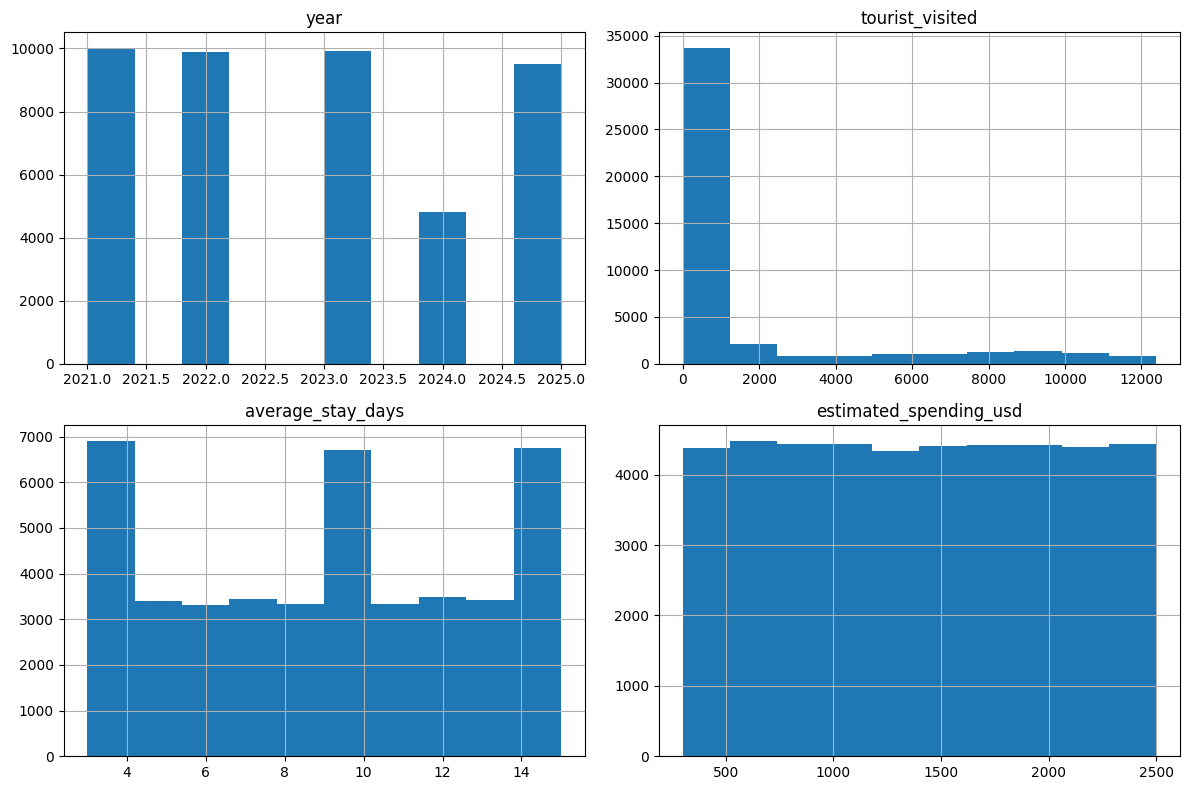

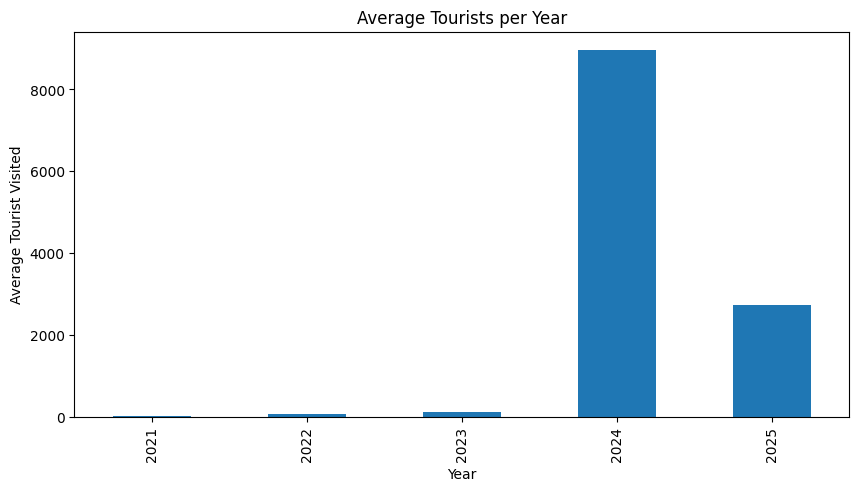

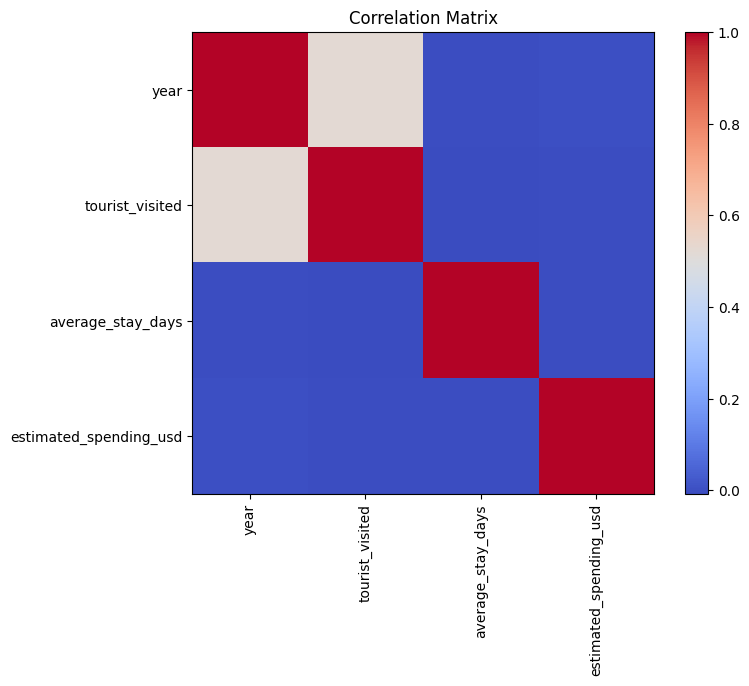

                            year  tourist_visited  average_stay_days  \
year                    1.000000         0.522494          -0.001274   
tourist_visited         0.522494         1.000000          -0.007508   
average_stay_days      -0.001274        -0.007508           1.000000   
estimated_spending_usd  0.001727        -0.002917          -0.001617   

                        estimated_spending_usd  
year                                  0.001727  
tourist_visited                      -0.002917  
average_stay_days                    -0.001617  
estimated_spending_usd                1.000000  


In [23]:
#data cleaning
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv('data.csv')

# Standardize column names
df.columns = df.columns.str.strip().str.lower().str.replace(' ','_')

# Remove duplicates
df = df.drop_duplicates()

# Handle missing values
for col in df.columns:
    if df[col].dtype=='object':
        df[col]=df[col].fillna(df[col].mode()[0] if not df[col].mode().empty else '')
    else:
        df[col]=df[col].fillna(df[col].median())

# Convert numeric columns where possible
for col in df.columns:
    try:
        df[col]=pd.to_numeric(df[col])
    except:
        pass

# Remove outliers (IQR)
num_cols=df.select_dtypes(include='number').columns
for col in num_cols:
    q1=df[col].quantile(0.25)
    q3=df[col].quantile(0.75)
    iqr=q3-q1
    lower=q1-1.5*iqr
    upper=q3+1.5*iqr
    df=df[(df[col]>=lower)&(df[col]<=upper)]

df.to_csv('cleaned_tourism_data.csv',index=False)
print(df.head())
print(df.shape)





# EDA
# =========================
# Exploratory Data Analysis
# =========================

print(df.info())

print(df.describe())

print(df.isnull().sum())

# Season-wise tourist count
print(df["season"].value_counts())

# Year-wise tourist count
print(df.groupby("year")["tourist_visited"].sum())

# Histograms
df.select_dtypes(include=np.number).hist(figsize=(12,8))
plt.tight_layout()
plt.show()

# Average Tourists per Year
plt.figure(figsize=(10,5))
df.groupby("year")["tourist_visited"].mean().plot(kind="bar")
plt.title("Average Tourists per Year")
plt.xlabel("Year")
plt.ylabel("Average Tourist Visited")
plt.show()

# Correlation Heatmap
corr = df.select_dtypes(include=np.number).corr()

plt.figure(figsize=(8,6))
plt.imshow(corr, cmap="coolwarm")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.colorbar()
plt.title("Correlation Matrix")
plt.show()

print(corr)


In [24]:
# Encoding
encoders={}
data=df.copy()
for c in data.select_dtypes(include='object').columns:
    le=LabelEncoder()
    data[c]=le.fit_transform(data[c])
    encoders[c]=le


Cluster
1    16099
2    13186
3    12826
0     7889
Name: count, dtype: int64
Silhouette: 0.32534321813747613


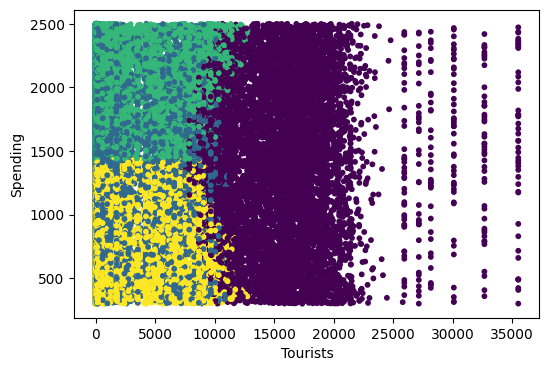

,Year,Month,Season,Country,Continent,Province,Region,Tourist_Destination,Tourist_Visited,Arrival_Mode,Purpose_of_Visit,Average_Stay_Days,Estimated_Spending_USD,Cluster
0,2021,January,Winter,Malaysia,Asia,Karnali,Mid-West,Shey Phoksundo,21,Air,Business,13,1929.47,1
1,2021,January,Winter,Canada,North America,Gandaki,Western,Mustang,14,Air,Trekking,15,2195.68,1
2,2021,January,Winter,India,Asia,Madhesh,Central,Janakpur,11,Land,Trekking,4,1540.73,2
3,2021,January,Winter,Thailand,Asia,Madhesh,Central,Parsa National Park,12,Air,Holiday,7,1021.87,3
4,2021,January,Winter,South Africa,Africa,Madhesh,Central,Parsa National Park,10,Air,Holiday,10,1612.83,1


In [ ]:
# KMeans Clustering
features=data[['Tourist_Visited','Average_Stay_Days','Estimated_Spending_USD']]
scaled=StandardScaler().fit_transform(features)
kmeans=KMeans(n_clusters=4,random_state=42,n_init=10)
clusters=kmeans.fit_predict(scaled)
df['Cluster']=clusters
print(df['Cluster'].value_counts())
print('Silhouette:',silhouette_score(scaled,clusters))
plt.figure(figsize=(6,4))
plt.scatter(df['Tourist_Visited'],df['Estimated_Spending_USD'],c=clusters,s=10)
plt.xlabel('Tourists')
plt.ylabel('Spending')
plt.show()
df.head()
